In [51]:
# 0. Google Drive Mount
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [52]:
# 1. Library Import & Seed
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics.pairwise import cosine_similarity

np.set_printoptions(precision=3, suppress=True)
tf.random.set_seed(42)
np.random.seed(42)


In [53]:
# 2. UCI HAR Dataset Load
DATASET_PATH = r"/content/drive/MyDrive/UCI HAR Dataset"


def load_uci_har(dataset_path):
    X_train_path = os.path.join(dataset_path, "train", "X_train.txt")
    y_train_path = os.path.join(dataset_path, "train", "y_train.txt")
    X_test_path  = os.path.join(dataset_path, "test", "X_test.txt")
    y_test_path  = os.path.join(dataset_path, "test", "y_test.txt")

    X_train = np.loadtxt(X_train_path).astype(np.float32)
    y_train = np.loadtxt(y_train_path).astype(np.int32)

    X_test = np.loadtxt(X_test_path).astype(np.float32)
    y_test = np.loadtxt(y_test_path).astype(np.int32)

    # UCI HAR의 X는 이미 561개 feature 형태
    # Conv1D encoder를 쓰기 위해 (N, 561, 1) 형태로 변환
    X_train = X_train[..., np.newaxis]   # (N, 561, 1)
    X_test  = X_test[..., np.newaxis]    # (N, 561, 1)

    # label을 0부터 시작하도록 변경: 1~6 -> 0~5
    y_train = y_train - 1
    y_test = y_test - 1

    return X_train, y_train, X_test, y_test


X_train, y_train, X_test, y_test = load_uci_har(DATASET_PATH)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)
print("X_train dtype:", X_train.dtype)
print("class labels :", np.unique(y_train))


X_train shape: (7352, 561, 1)
y_train shape: (7352,)
X_test shape : (2947, 561, 1)
y_test shape : (2947,)
X_train dtype: float32
class labels : [0 1 2 3 4 5]


In [54]:
# 3. HAR Augmentation

def jitter(x, sigma=0.03):
    """
    원본 센서 값에 0 근처의 작은 noise를 더함.
    센서 측정 오차나 미세한 움직임 차이를 반영.
    """
    x = tf.cast(x, tf.float32)

    noise = tf.random.normal(
        shape=tf.shape(x),
        mean=0.0,
        stddev=sigma,
        dtype=tf.float32
    )

    x_jitter = x + noise
    return x_jitter, noise


def scaling(x, sigma=0.1):
    """
    1 근처의 scaling factor를 곱함.
    사람마다 다른 움직임 강도나 센서 착용 상태에 따른 신호 크기 차이를 반영.
    """
    x = tf.cast(x, tf.float32)

    x_shape = tf.shape(x)
    x_rank = tf.rank(x)

    # x shape 예시: (batch, 561, 1)
    # factor shape: (batch, 1, 1)
    # batch 차원만 유지하고 나머지는 1로 맞춰 broadcasting
    factor_shape = tf.concat(
        [
            [x_shape[0]],
            tf.ones(x_rank - 1, dtype=tf.int32)
        ],
        axis=0
    )

    factor = tf.random.normal(
        shape=factor_shape,
        mean=1.0,
        stddev=sigma,
        dtype=tf.float32
    )

    x_scaled = x * factor
    return x_scaled, factor


def augment_with_info(x):
    """
    변형 전/후 확인용 augmentation 함수.
    원본, noise, jitter 결과, scaling factor까지 반환.
    """
    x_original = tf.cast(x, tf.float32)
    x_jitter, noise = jitter(x_original)
    x_augmented, factor = scaling(x_jitter)

    return x_augmented, x_original, x_jitter, noise, factor


def augment(x):
    """
    학습용 augmentation 함수.
    최종 augmented view만 반환.
    """
    x_augmented, _, _, _, _ = augment_with_info(x)
    return x_augmented


In [55]:
# 4. Augmentation 결과 확인
sample_batch = X_train[:1]

view1, original1, jitter1, noise1, factor1 = augment_with_info(sample_batch)
view2, original2, jitter2, noise2, factor2 = augment_with_info(sample_batch)

print("원본 앞 5개:")
print(original1[0, :5, 0].numpy())

print("view1 noise 앞 5개:")
print(noise1[0, :5, 0].numpy())

print("view1 jitter 후 앞 5개:")
print(jitter1[0, :5, 0].numpy())

print("view1 scaling factor:")
print(factor1[0].numpy().squeeze())

print("view1 최종 값 앞 5개:")
print(view1[0, :5, 0].numpy())

print("----------------------------")

print("view2 noise 앞 5개:")
print(noise2[0, :5, 0].numpy())

print("view2 jitter 후 앞 5개:")
print(jitter2[0, :5, 0].numpy())

print("view2 scaling factor:")
print(factor2[0].numpy().squeeze())

print("view2 최종 값 앞 5개:")
print(view2[0, :5, 0].numpy())


원본 앞 5개:
[ 0.289 -0.02  -0.133 -0.995 -0.983]
view1 noise 앞 5개:
[ 0.01  -0.025  0.01  -0.042 -0.072]
view1 jitter 후 앞 5개:
[ 0.298 -0.046 -0.123 -1.038 -1.055]
view1 scaling factor:
1.0084225
view1 최종 값 앞 5개:
[ 0.301 -0.046 -0.124 -1.046 -1.064]
----------------------------
view2 noise 앞 5개:
[-0.017 -0.016  0.071 -0.047  0.024]
view2 jitter 후 앞 5개:
[ 0.272 -0.036 -0.062 -1.042 -0.959]
view2 scaling factor:
1.0656487
view2 최종 값 앞 5개:
[ 0.29  -0.039 -0.066 -1.111 -1.022]


In [56]:
# 5. Encoder Model

def build_encoder(input_shape, embedding_dim=128):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv1D(64, kernel_size=7, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = layers.Conv1D(128, kernel_size=5, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = layers.Conv1D(128, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    x = layers.GlobalAveragePooling1D()(x)

    # encoder의 최종 출력: embedding vector
    outputs = layers.Dense(embedding_dim, name="embedding")(x)

    model = models.Model(inputs, outputs, name="encoder")
    return model


input_shape = X_train.shape[1:]  # (561, 1)

encoder = build_encoder(
    input_shape=input_shape,
    embedding_dim=128
)

encoder.summary()


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 561, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 561, 64)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 561, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 280, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 280, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 280, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 140, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 140, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 140, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Dense)               │ (None, 128)            │        16,512 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,672 (424.50 KB)

 Trainable params: 108,032 (422.00 KB)

 Non-trainable params: 640 (2.50 KB)

In [57]:
# 5-1. Encoder Embedding Vector 확인
# 같은 view1, view2를 한 번만 만들고 재사용해야 값 비교가 일관됨

sample_batch = X_train[:1]

view1 = augment(sample_batch)
view2 = augment(sample_batch)

# encoder output: embedding vector
emb1 = encoder(view1, training=False)
emb2 = encoder(view2, training=False)

print("view1 shape:", view1.shape)
print("view2 shape:", view2.shape)

print("\nview1 embedding shape:", emb1.shape)
print("view2 embedding shape:", emb2.shape)

print("\nview1 embedding 앞 5개:")
print(emb1[0, :5].numpy())

print("\nview2 embedding 앞 5개:")
print(emb2[0, :5].numpy())

view1 shape: (1, 561, 1)
view2 shape: (1, 561, 1)

view1 embedding shape: (1, 128)
view2 embedding shape: (1, 128)

view1 embedding 앞 5개:
[-0.016  0.019  0.025 -0.039 -0.055]

view2 embedding 앞 5개:
[-0.018  0.021  0.028 -0.044 -0.061]


In [58]:
# Encoder Embedding Similarity 확인 함수
# encoder output embedding vector 기준으로
# positive pair와 negative pair의 cosine similarity를 확인함.
# projection head는 사용하지 않음.

def check_encoder_embedding_similarity(encoder, X_data, title="Encoder Embedding Similarity", n_samples=10):
    print("=" * 60)
    print(title)
    print("=" * 60)

    sample_x = X_data[:n_samples]

    # 같은 원본 batch에서 view 2개 생성
    view1 = augment(sample_x)
    view2 = augment(sample_x)

    # encoder output: embedding vector
    h1 = encoder(view1, training=False)
    h2 = encoder(view2, training=False)

    print("view1 shape:", view1.shape)
    print("view2 shape:", view2.shape)
    print("h1 embedding shape:", h1.shape)
    print("h2 embedding shape:", h2.shape)

    # cosine similarity 계산을 위해 L2 normalize
    h1_norm = tf.math.l2_normalize(h1, axis=1)
    h2_norm = tf.math.l2_normalize(h2, axis=1)

    print("\nPositive pair similarity:")
    for i in range(h1.shape[0]):
        # 같은 sample i에서 나온 view1과 view2 비교
        sim = tf.reduce_sum(h1_norm[i] * h2_norm[i])
        print(f"sample {i} view1-view2 similarity: {sim.numpy():.8f}")

    print("\nNegative pair similarity:")
    for i in range(h1.shape[0] - 1):
        # sample i의 view1과 sample i+1의 view2 비교
        sim = tf.reduce_sum(h1_norm[i] * h2_norm[i + 1])
        print(f"sample {i} view1 vs sample {i+1} view2 similarity: {sim.numpy():.8f}")

In [59]:
# 5-2. 학습 전 Encoder Embedding Similarity 확인

check_encoder_embedding_similarity(
    encoder=encoder,
    X_data=X_train,
    title="Before Contrastive Learning",
    n_samples=10
)

Before Contrastive Learning
view1 shape: (10, 561, 1)
view2 shape: (10, 561, 1)
h1 embedding shape: (10, 128)
h2 embedding shape: (10, 128)

Positive pair similarity:
sample 0 view1-view2 similarity: 0.99999386
sample 1 view1-view2 similarity: 0.99999511
sample 2 view1-view2 similarity: 0.99999392
sample 3 view1-view2 similarity: 0.99999386
sample 4 view1-view2 similarity: 0.99999493
sample 5 view1-view2 similarity: 0.99999100
sample 6 view1-view2 similarity: 0.99999213
sample 7 view1-view2 similarity: 0.99999154
sample 8 view1-view2 similarity: 0.99998987
sample 9 view1-view2 similarity: 0.99999511

Negative pair similarity:
sample 0 view1 vs sample 1 view2 similarity: 0.99774802
sample 1 view1 vs sample 2 view2 similarity: 0.99988079
sample 2 view1 vs sample 3 view2 similarity: 0.99992490
sample 3 view1 vs sample 4 view2 similarity: 0.99991846
sample 4 view1 vs sample 5 view2 similarity: 0.99995565
sample 5 view1 vs sample 6 view2 similarity: 0.99992633
sample 6 view1 vs sample 7 vie

In [60]:
# 6. Projection Head

def build_projection_head(embedding_dim=128, projection_dim=64):
    inputs = layers.Input(shape=(embedding_dim,))

    x = layers.Dense(128, activation="relu")(inputs)
    outputs = layers.Dense(projection_dim)(x)

    model = models.Model(inputs, outputs, name="projection_head")
    return model


projection_head = build_projection_head(
    embedding_dim=128,
    projection_dim=64
)

projection_head.summary()


Model: "projection_head"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,768 (96.75 KB)

 Trainable params: 24,768 (96.75 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
# 6-1. Projection Vector 확인
# 5에서 만든 emb1, emb2를 재사용함.
# projection head output은 contrastive loss 계산용 vector.

proj1 = projection_head(emb1, training=False)
proj2 = projection_head(emb2, training=False)

print("view1 projection shape:", proj1.shape)
print("view2 projection shape:", proj2.shape)

print("\nview1 projection 앞 10개:")
print(proj1[0, :10].numpy())

print("\nview2 projection 앞 10개:")
print(proj2[0, :10].numpy())

view1 projection shape: (1, 64)
view2 projection shape: (1, 64)

view1 projection 앞 10개:
[ 0.061 -0.031 -0.085  0.027 -0.031  0.064  0.045 -0.016 -0.04   0.027]

view2 projection 앞 10개:
[ 0.067 -0.035 -0.095  0.03  -0.034  0.071  0.05  -0.018 -0.045  0.03 ]


In [62]:
# 7. NT-Xent Contrastive Loss

def nt_xent_loss(z1, z2, temperature=0.2):
    """
    z1: view1 projection, shape (batch, projection_dim)
    z2: view2 projection, shape (batch, projection_dim)
    """
    batch_size = tf.shape(z1)[0]

    # cosine similarity 계산을 위해 normalization
    z1 = tf.math.l2_normalize(z1, axis=1)
    z2 = tf.math.l2_normalize(z2, axis=1)

    # view1과 view2를 하나로 합침: (2B, dim)
    z = tf.concat([z1, z2], axis=0)

    # 전체 similarity matrix: (2B, 2B)
    similarity_matrix = tf.matmul(z, z, transpose_b=True)
    similarity_matrix = similarity_matrix / temperature

    # 자기 자신과의 similarity는 제외
    mask = tf.eye(2 * batch_size, dtype=tf.float32)
    similarity_matrix = similarity_matrix + mask * -1e9

    # positive pair index
    # batch size가 B일 때, 0의 positive는 B, 1의 positive는 B+1
    labels = tf.concat([
        tf.range(batch_size, 2 * batch_size),
        tf.range(0, batch_size)
    ], axis=0)

    loss = tf.keras.losses.sparse_categorical_crossentropy(
        labels,
        similarity_matrix,
        from_logits=True
    )

    return tf.reduce_mean(loss)


In [63]:
# 8. Contrastive Pretraining
BATCH_SIZE = 128
PRETRAIN_EPOCHS = 10

train_dataset = tf.data.Dataset.from_tensor_slices(X_train)
train_dataset = train_dataset.shuffle(2048).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

for epoch in range(PRETRAIN_EPOCHS):
    total_loss = 0.0
    step_count = 0

    for batch_x in train_dataset:
        with tf.GradientTape() as tape:
            # 같은 HAR window에서 view 2개 생성
            x_view1 = augment(batch_x)
            x_view2 = augment(batch_x)

            # encoder 통과: embedding
            h1 = encoder(x_view1, training=True)
            h2 = encoder(x_view2, training=True)

            # projection head 통과: contrastive loss 계산용 vector
            z1 = projection_head(h1, training=True)
            z2 = projection_head(h2, training=True)

            # contrastive loss 계산
            loss = nt_xent_loss(z1, z2, temperature=0.2)

        variables = encoder.trainable_variables + projection_head.trainable_variables
        gradients = tape.gradient(loss, variables)
        optimizer.apply_gradients(zip(gradients, variables))

        total_loss += loss.numpy()
        step_count += 1

    avg_loss = total_loss / step_count
    print(f"Epoch [{epoch+1}/{PRETRAIN_EPOCHS}] Contrastive Loss: {avg_loss:.4f}")

# 이후 downstream task에서 사용할 pretrained encoder
pretrained_encoder = encoder


Epoch [1/10] Contrastive Loss: 2.4310
Epoch [2/10] Contrastive Loss: 1.5329
Epoch [3/10] Contrastive Loss: 1.4021
Epoch [4/10] Contrastive Loss: 1.3646
Epoch [5/10] Contrastive Loss: 1.3377
Epoch [6/10] Contrastive Loss: 1.3147
Epoch [7/10] Contrastive Loss: 1.2950
Epoch [8/10] Contrastive Loss: 1.2881
Epoch [9/10] Contrastive Loss: 1.2810
Epoch [10/10] Contrastive Loss: 1.2716


In [64]:
# 9. 학습 후 Encoder Embedding Similarity 확인

check_encoder_embedding_similarity(
    encoder=encoder,
    X_data=X_train,
    title="After Contrastive Learning",
    n_samples=10
)

After Contrastive Learning
view1 shape: (10, 561, 1)
view2 shape: (10, 561, 1)
h1 embedding shape: (10, 128)
h2 embedding shape: (10, 128)

Positive pair similarity:
sample 0 view1-view2 similarity: 0.99805862
sample 1 view1-view2 similarity: 0.99104524
sample 2 view1-view2 similarity: 0.98530424
sample 3 view1-view2 similarity: 0.99060071
sample 4 view1-view2 similarity: 0.94727039
sample 5 view1-view2 similarity: 0.98324710
sample 6 view1-view2 similarity: 0.98314834
sample 7 view1-view2 similarity: 0.96753049
sample 8 view1-view2 similarity: 0.98645449
sample 9 view1-view2 similarity: 0.93134677

Negative pair similarity:
sample 0 view1 vs sample 1 view2 similarity: 0.08760720
sample 1 view1 vs sample 2 view2 similarity: 0.69719791
sample 2 view1 vs sample 3 view2 similarity: 0.57230115
sample 3 view1 vs sample 4 view2 similarity: 0.77172512
sample 4 view1 vs sample 5 view2 similarity: 0.79368985
sample 5 view1 vs sample 6 view2 similarity: 0.57620728
sample 6 view1 vs sample 7 view

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


/tmp/ipykernel_3940/141993812.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(class_names))


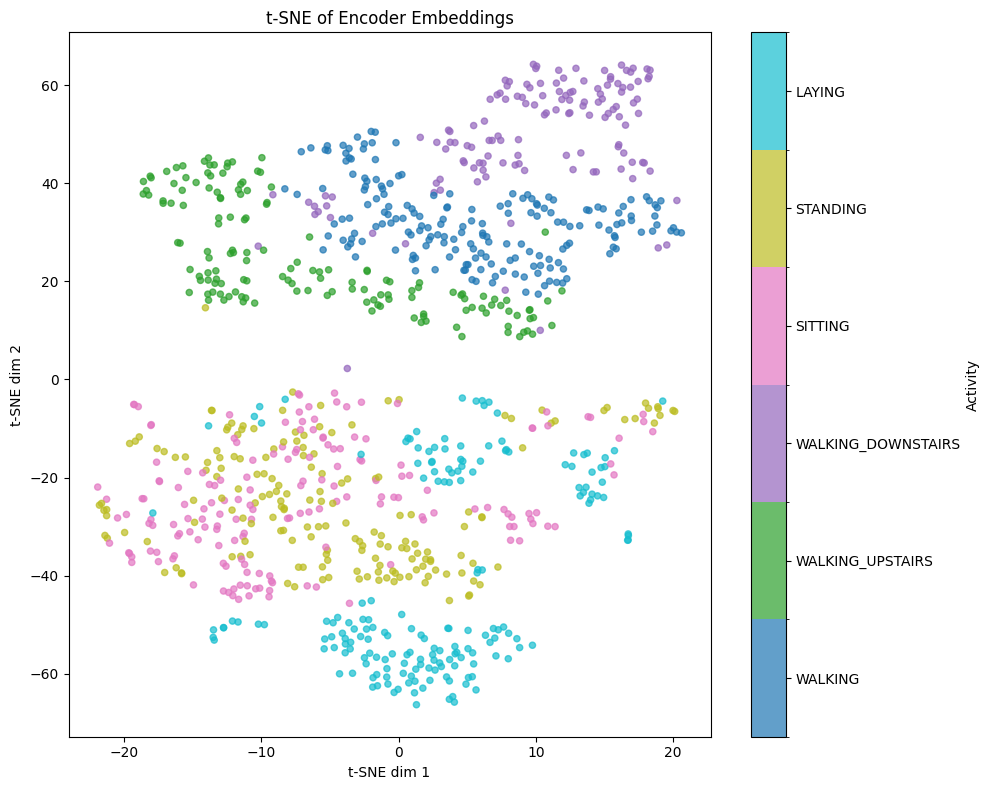

In [71]:
# ============================================================
# 10. t-SNE 시각화 - 학습 후 Encoder Embedding
# ============================================================
# contrastive learning이 끝난 encoder의 embedding을 2차원으로 시각화
# 오른쪽 colorbar에 숫자 대신 activity label 이름을 표시함.

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

n_samples = 1000

sample_x = X_test[:n_samples]
sample_y = y_test[:n_samples]

# 학습 후 encoder output embedding 추출
embeddings = encoder.predict(sample_x)

# t-SNE 적용: 128차원 embedding -> 2차원 좌표
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

tsne_result = tsne.fit_transform(embeddings)

# discrete colorbar 설정
cmap = plt.cm.get_cmap("tab10", len(class_names))
bounds = np.arange(len(class_names) + 1) - 0.5
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)

# 시각화
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    tsne_result[:, 0],
    tsne_result[:, 1],
    c=sample_y,
    cmap=cmap,
    norm=norm,
    s=20,
    alpha=0.7
)

plt.title("t-SNE of Encoder Embeddings")
plt.xlabel("t-SNE dim 1")
plt.ylabel("t-SNE dim 2")

# colorbar 숫자 대신 activity 이름 표시
cbar = plt.colorbar(
    scatter,
    ticks=np.arange(len(class_names))
)
cbar.set_ticklabels(class_names)
cbar.set_label("Activity")

plt.tight_layout()
plt.show()